## Predicting location of hyperbolas Instance Segmentation

In this notebook, the workflow is the same as in 4_Predicting_location_of_hyperbolas_Object_Detection, except that the model used here is an instance segmentation model.

- Chapter 1: Load Yolo Model
- Chapter 2: Predicting Locations of Hyperbolas with YOLO Model
- Chapter 3: Extracting Bounding Boxes and Polygons
- Chapter 4: Create a file out of the Predictions and Convert the Predictions to 3D
- Chapter 5: Fitting Hyperbolas with Multiple Linear Regression
- Chapter 6: Interactive Plot
- Chapter 7: Implementation in Pipeline



### Chapter 1: Load Yolo Model

The following code shows how to load a YOLO model directly through the ultralytics library. The model was trained beforehand, and the training process is explained in detail in the notebook Training_and_Evaluate_Tune_Yolo_model.

In [1]:
#import libraries
import numpy as np
from ultralytics import YOLO

#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *




In [2]:
#Load trained Model for Instance Segmentation for Hyperbolas
model = YOLO(YOLO_MODEL_SEG_H_DIR)


Load the Datatoolkit and create Test Images if wanted via the Datatoolkit.

In [3]:
from Pipeline.Datatoolkit import DatatoolKit

dk1 = DatatoolKit(TEST_FILE_DIR , "EG-3D QUER001.SGY")
dk2 = DatatoolKit(TEST_FILE_DIR , "UG3DQUERUNTERZUG.SGY")
file1 = dk1.LoadSGY()
file2 = dk2.LoadSGY()
df1 = dk1.create_df(file1)
df2 = dk2.create_df(file2)

In [6]:
dk1.create_images(file=file1, df=df1, outdir=TEST_PIC_SEG_H_DIR, inline=True)

saved 71 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\EG-3D QUER001.SGY_inline_71.png


In [ ]:
dk2.create_images(file=file2, df= df2, outdir=TEST_PIC_SEG_H_DIR, inline=True)

saved 60 images to c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\pictures\UG3DQUERUNTERZUG.SGY_inline_60.png


## Chapter 2: Predicting Locations of Hyperbolas with YOLO Model

In [4]:
results = model.predict(TEST_PIC_SEG_H_DIR,save =True, conf=0.2, show_boxes = True)


image 1/60 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_1.png: 384x640 16 hyperbolas, 122.4ms
image 2/60 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_10.png: 384x640 18 hyperbolas, 63.9ms
image 3/60 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_11.png: 384x640 18 hyperbolas, 61.1ms
image 4/60 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_12.png: 384x640 20 hyperbolas, 61.2ms
image 5/60 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_13.png: 384x640 20 hyperbolas, 60.6ms
image 6/60 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperbola\pictures\UG3DQUERUNTERZUG.SGY_inline_14.png: 384x640 19 hyperbolas, 59.3ms
image 7/60 c:\pythonad\PAINDHS25\PAINDGPR\Data\Testdata\Segmentation_Hyperb


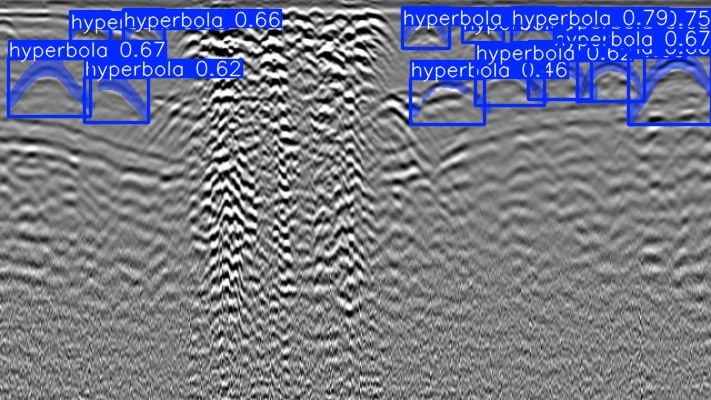

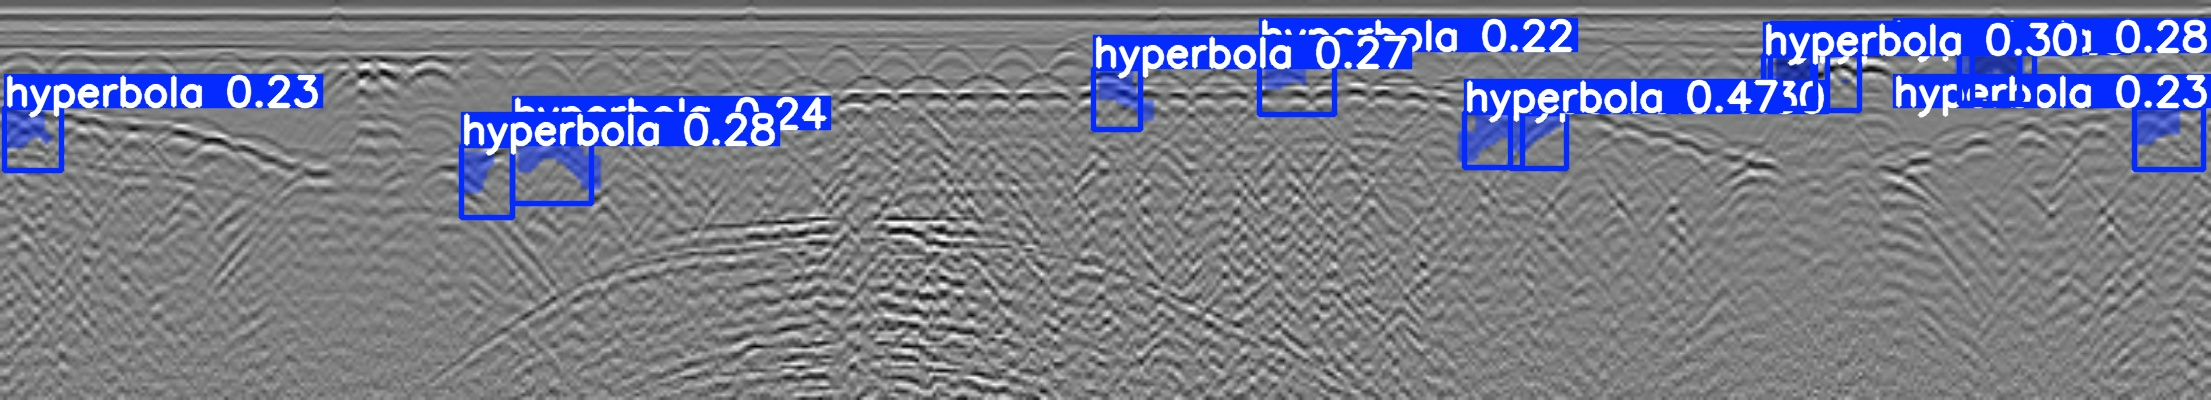

From these two examples, it can be clearly seen that this type of model performs better than the object detection approach.
However, in the second image, not as many hyperbolas are detected as expected this may be due to the limited amount of training data.

### Chapter 3: Extracting Bounding Boxes and Polygons

Now, the function for extracting boxes created in **4_Predicting_location_of_hyperbolas_Object_Detection.ipynb** is modified and adjusted so that it can extract both the polygons and the bounding boxes.

In [ ]:
import os
import numpy as np

def extract_boxes_and_polygons(results)-> dict:
    
    
    all_results = {}

    # process each result
    for result in results:

        # get image name
        img_name = os.path.basename(result.path)
        data = {}

        # extract boxes and confidences
        if result.boxes is not None:
            data["boxes"] = result.boxes.xyxy.cpu().numpy()
            data["conf"] = result.boxes.conf.cpu().numpy()
            
        else:
            data["boxes"] = np.empty((0,4)) 
            data["conf"] = np.empty((0,))      
        
        # extract polygons if available
        if hasattr(result, "masks") and result.masks is not None:
            print("found polys")
            polygons = [mask.xy[0].tolist() for mask in result.masks]
            data["polygons"] = polygons
            
        
        else:
            data["polygons"] = []

        # store results for this image
        all_results[img_name] = data
    return all_results

In [5]:
preds = extract_boxes_and_polygons(results)
print(preds)

found polys
found polys
found polys
found polys
found polys
found polys
found polys
found polys
found polys
{'EG-3D QUER001.SGY_inline_15.png': {'boxes': array([[     396.41,      50.695,       471.7,      114.78],
       [      437.5,      156.54,      505.19,      229.03],
       [     1866.5,      155.15,      1965.5,      250.02],
       [     1735.2,      46.499,      1817.3,       111.1]], dtype=float32), 'conf': array([     0.5658,     0.56179,      0.5484,     0.51444], dtype=float32), 'polygons': [[[393.8343505859375, 54.90312576293945], [393.8343505859375, 92.9046859741211], [404.19842529296875, 92.9046859741211], [411.1077880859375, 85.99530792236328], [414.5625, 85.99530792236328], [418.0171813964844, 82.5406265258789], [421.47186279296875, 82.5406265258789], [424.9265441894531, 79.0859375], [428.3812255859375, 79.0859375], [431.8359375, 75.6312484741211], [435.2906188964844, 75.6312484741211], [445.6546630859375, 85.99530792236328], [449.109375, 85.99530792236328], [456.01

### Chapter 4: Create a file out of the Predictions and Convert the Predictions to 3D

The goal is to create a CSV file that contains:

1. All bounding boxes that are indexed, and

2. All polygons that are associated with or derived from—those bounding boxes.

The main challenge is to establish a clear relationship between the images, their bounding boxes, and the corresponding polygon segments.
The first step is to define a well-structured schema for the CSV file.
This schema will specify:

1. which information each entry must contain,

2. how bounding boxes and polygons are linked together,

3. and how images are uniquely referenced

The idea behind this structure is to use the bounding boxes as global objects in order to place the polygons into a 3D context.
This is done by comparing the centers of all bounding boxes across all inline cuts:

- If the Euclidean distance between centers is larger than a certain threshold, a new global bounding box is created.

- Otherwise, the polygons are matched to an existing global bounding box.

Thus, the structure looks as follows and for each Polygon there is a new row created:

|filename|cut_type|cut_number|bbox_number|bbox_data|polygon_data|
|-|-|-|-|-|-|
|file1|inline|1|1|[20,30,40,50]|Ponits of polygon in bbox|

to recreate the structure the extracting function from **Chapter 3** needs to be adjusted.

In [5]:
import os
import numpy as np
import re
import pandas as pd
import json

def match_detections(results, dist_trheshhold:int=20, export_csv:bool = False, save_path:str = None):
    global_boxes = []
    global_id = 0
    records = []

    # get center of bbox
    def center_bbox(box):
        x1,y1,x2,y2 = box
        return ((x1+x2)/2, (y1+y2)/2)
    
    # calculate Euclidean distance between two centers
    def euclidan_distance(c1, c2):
        return np.sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)
    
    # parse filename to extract relevant parts
    def parse_filename(filename):
        base_name = os.path.basename(filename)
        
        #getting everything until SGY
        match_main = re.match(r"(.+?\.SGY)", base_name, re.IGNORECASE)
        filename_part = match_main.group(1) if match_main else base_name

        #getting cut_type and cut_number
        match_suffix = re.search(r"_(\w+)[_-](\d+)", base_name)
        cut_type = match_suffix.group(1) if match_suffix else "unknown"
        cut_number = int(match_suffix.group(2)) if match_suffix else -1

        return filename_part, cut_type, cut_number


    # process each result
    for result in results:

        # get image name
        img = os.path.basename(result.path)
        filename, cut_type, cut_number = parse_filename(img)

        # extract boxes
        if result.boxes is not None:
            boxes = result.boxes.xyxy.cpu().numpy()
           
        else:
            boxes = np.empty((0,4)) 
                  
        # extract polygons if available
        if hasattr(result, "masks") and result.masks is not None:
            polygons = [mask.tolist() for mask in result.masks.xy]
            
        else:
            polygons = []

        # match boxes to global IDs
        for i, box in enumerate(boxes):
            center = center_bbox(box)
            existing_id = None

            # check against existing global boxes
            for gid, gcenter in global_boxes:
                if euclidan_distance(center, gcenter)< dist_trheshhold:
                    existing_id = gid
                    break
            
            # assign new ID if no match found
            if existing_id is None:
                existing_id = global_id
                global_boxes.append((global_id,center))
                global_id +=1

            # prepare record
            polygon_data = json.dumps(polygons[i] if i < len(polygons) else [])
            bbox_data = json.dumps(box.tolist())
            

            # store record
            records.append({
                "filename": filename,
                "cut_type": cut_type,
                "cut_number": cut_number,
                "bbox_number": existing_id,
                "bbox_data": bbox_data,
                "polygon_data": polygon_data
            })

    # create DataFrame
    matched_detections = pd.DataFrame(records)

    # export to CSV if needed
    if export_csv:
        matched_detections.to_csv(f"{save_path}/results.csv", index=False)
        return matched_detections
    else:
        return matched_detections

Next step is to test the function

In [6]:
matched_detections = match_detections(results= results, dist_trheshhold=20, save_path=OUT_PATH_Detections, export_csv=True )

In [7]:
matched_detections

,filename,cut_type,cut_number,bbox_number,bbox_data,polygon_data
0,UG3DQUERUNTERZUG.SGY,inline,1,0,"[564.8929443359375, 9.323530197143555, 606.538...","[[575.4656372070312, 11.140625], [575.46563720..."
1,UG3DQUERUNTERZUG.SGY,inline,1,1,"[119.51518249511719, 7.599554538726807, 165.42...","[[133.3125, 6.696875095367432], [133.3125, 11...."
2,UG3DQUERUNTERZUG.SGY,inline,1,2,"[512.0293579101562, 8.925403594970703, 553.642...","[[522.140625, 11.140625], [522.140625, 14.4734..."
3,UG3DQUERUNTERZUG.SGY,inline,1,3,"[457.6700439453125, 9.530701637268066, 501.564...","[[469.92657470703125, 11.140625], [469.9265747..."
4,UG3DQUERUNTERZUG.SGY,inline,1,4,"[520.1708374023438, 60.12672805786133, 594.235...","[[543.2484130859375, 60.02187728881836], [543...."
...,...,...,...,...,...,...
1114,UG3DQUERUNTERZUG.SGY,inline,9,14,"[273.74169921875, 11.164473533630371, 321.9167...","[[307.72967529296875, 46.69062423706055], [307..."
1115,UG3DQUERUNTERZUG.SGY,inline,9,5,"[401.17938232421875, 11.112383842468262, 440.2...","[[412.1578063964844, 11.140625], [412.15780639..."
1116,UG3DQUERUNTERZUG.SGY,inline,9,19,"[225.04153442382812, 14.01787281036377, 247.03...","[[224.4093780517578, 15.584375381469727], [224..."
1117,UG3DQUERUNTERZUG.SGY,inline,9,16,"[471.86920166015625, 61.070472717285156, 533.4...","[[488.8125, 60.02187728881836], [488.8125, 63...."


This looks promising with respect to the DataFrame. However, for better interpretation a plot is needed.


In [8]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

def plot_matched_detections(df, csv:bool=False, csv_path:str = None):
    # load data
    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    # create 3D plot
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(projection='3d')

    # plot each polygon
    for i, row in df.iterrows():
        
        cut_number = row["cut_number"]
        polys = row["polygon_data"]
        bbox_number = row["bbox_number"]

        try:
            polygon = json.loads(polys)
        
        except json.JSONDecodeError:
            continue
        
        # skip if polygon is empty or invalid
        if not polygon or not isinstance(polygon[0], (list, tuple)):
            continue
        
        # extract x and y coordinates
        xs = [p[0] for p in polygon]
        zs = [p[1] for p in polygon]
        ys = [cut_number]

        # plot with color based on bbox_number
        color = cm.tab20(int(bbox_number)%20)
        ax.plot(xs, ys, zs, color = color, linewidth = 0.8,alpha = 0.5)

    ax.set_xlim(0,711)
    ax.set_zlim(0,400)
    ax.set_xlabel("X Values Polygons")
    ax.set_ylabel("Cut_number")
    ax.set_zlabel("Y Values Polygons")
    ax.invert_zaxis()

    ax.set_title("3D Plot of Detections")

    plt.show()



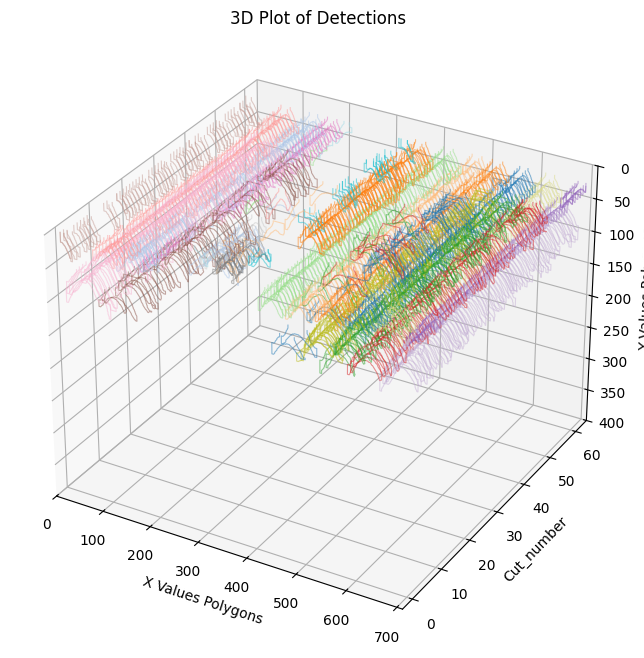

In [9]:
plot_matched_detections(df=matched_detections)

From the first plot, it is not entirely clear which hyperbolas belong to which inline. Therefore, the next plot includes the different cuts to make this distinction visible.

In [10]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

def plot_matched_detections(df, csv:bool=False, csv_path:str = None):
    
    xlim = (0,711)
    zlim = (0,400)

    # load data
    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    # create 3D plot
    fig = plt.figure(figsize=(15,15))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect([1,1,1])

    # plot cut planes
    cuts = sorted(df["cut_number"].unique())
    X, Z = np.meshgrid(np.linspace(xlim[0],xlim[1],10),
                       np.linspace(zlim[0], zlim[1], 10))
    
    # plot each cut plane
    for cut in cuts:
        Y = np.ones_like(X) * cut
        ax.plot_surface(X, Y, Z, color="gray", alpha = 0.02, linewidth = 0.3)


    # plot each polygon
    for i, row in df.iterrows():

        cut_number = row["cut_number"]
        polys = row["polygon_data"]
        bbox_number = row["bbox_number"]

        try:
            polygon = json.loads(polys)
        
        except json.JSONDecodeError:
            continue

        if not polygon or not isinstance(polygon[0], (list, tuple)):
            continue
        # extract x and y coordinates
        xs = [p[0] for p in polygon]
        zs = [p[1] for p in polygon]
        ys = [cut_number]

        # plot with color based on bbox_number
        color = cm.tab20(int(bbox_number)%20)
        ax.plot(xs, ys, zs, color = color, linewidth = 0.9,alpha = 0.8,
                label= f"Bounding Box {int(bbox_number)}")

    # create legend without duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Bounding Boxes", loc="upper left",
              bbox_to_anchor = (0, 0., 0.5, 1),
              framealpha = 0.0, fontsize = 7)

    ax.set_xlim(xlim[0], xlim[1])
    ax.set_zlim(zlim[0], zlim[1])
    ax.set_xlabel("X Values Polygons = Crosslines")
    ax.set_ylabel("Inline")
    ax.set_zlabel("Y Values Polygons = Time Sample")
    ax.invert_zaxis()

    ax.set_title("3D Plot of Detections")

    plt.show()



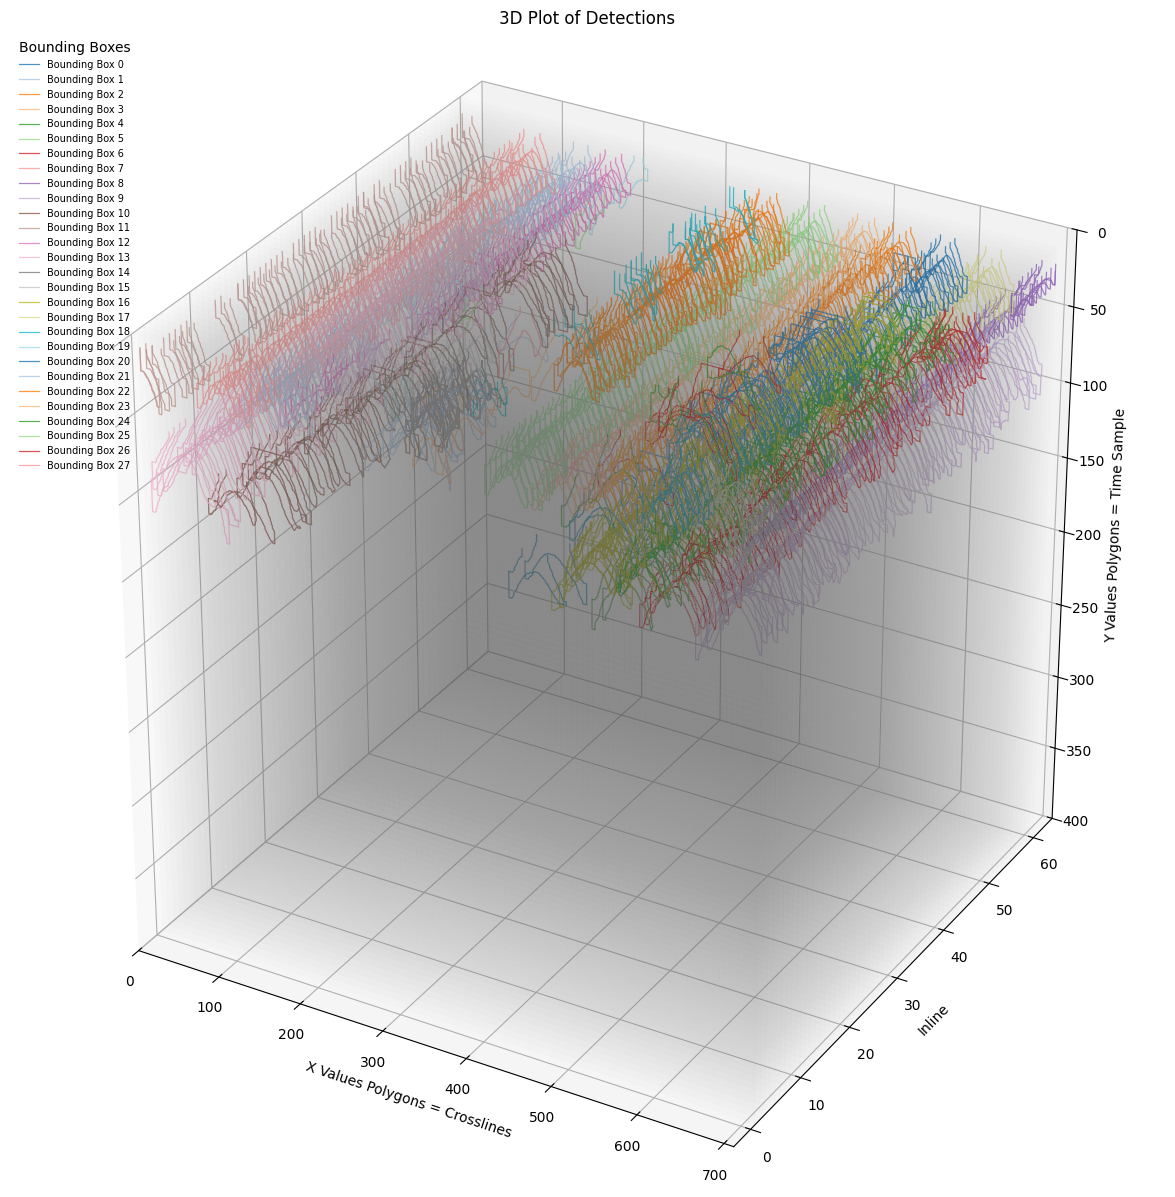

In [11]:
plot_matched_detections(df = matched_detections)

This looks better, but there still needs to be a way to verify whether all detections are included in both the CSV and the plot.
Therefore, the next step is to create a function that compares the number of polygons in the CSV or DataFrame with the number of detections produced by YOLO. Since there each Polygon is on a diffrent row thw idea ist to compare the number of rows with the Number of detections out of the results.

In [12]:
def validate_detections(matched_detections,results, csv:bool = False, csv_path:str = None):

    # load data
    if csv:
        matched_df = pd.read_csv(csv_path, sep=",")
    else:
        matched_df = matched_detections

    # count detections csv
    number_detections_csv_total = matched_df.shape[0]

    
    number_of_detections_results = 0

    # count detections from results
    for result in results:
        if result.masks.xy is not None:
            number_of_detections_results += len(result.masks.xy)

    # compare counts
    if number_detections_csv_total == number_of_detections_results:
        print("Detections YOLO matching with Matched Detections")
    
    else:
        print(f"Yolo Detections:{number_of_detections_results} Number of Matched Detections {number_detections_csv_total}")

    


In [13]:
validate_detections(matched_detections=matched_detections,results=results)

Detections YOLO matching with Matched Detections


### Chapter 5: Fitting Hyperbolas with multiple Linear Regression

For fitting the Hyperbolas on the polygon data the idea is to use
Multiple Linear Regression for the cylindric hyperboloid. unfortunality ther has been no data for hyperboloids so it only could be done for cylindric hyperboloids.
The corresponding formula is:

t² = (4 / v²) · (x – x₀)² + t₀²

Expanding the square gives the linear-regression-compatible form:

t² = b₀ + b₁ x + b₂ x²

with the coefficients:

b₂ = 4 / v²  
b₁ = –8 x₀ / v²  
b₀ = 4 x₀² / v² + t₀²

After the regression the physical parameters are recovered via:

v   = 2 / √b₂  
x₀  = – b₁ / (4 b₂)  
t₀  = √( b₀ – b₁² / (4 b₂) )


The next function performs a fit for every polygon on every cut. This means that on each cut, every detected polygon is fitted independently.

In [14]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import json

def fit_hyperbolas_on_every_cut(df, csv:bool=False, csv_path:str = None):
    # load data
    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    # initialize list to store fit results
    fits = []

    # iterate over each row in the dataframe
    for i, row in df.iterrows():
        #Fit Hyperbolas with multiplie Regression
        polygon =  json.loads(row["polygon_data"])
        bbox = row["bbox_number"]
        polygon = np.array(polygon)

        # prepare data for regression
        x = polygon[:,0]
        t = polygon[:,1]
        t = t

        # define design matrix for fit
        y = t**2
        X = np.column_stack([np.ones_like(x), x, x**2])
        model = LinearRegression(fit_intercept=False)
        model.fit(X,y)

        # extract coefficients
        print(f"polygon:{i} in bbox:{bbox} , coefficients{model.coef_}")
        b0, b1, b2 = model.coef_

        #Convert Coefficients to Hyperbel context
        v = np.sqrt((4/b2))
        x0 = (-b1) / (2*b2)
        t0 = np.sqrt(b0 -b1**2 / ( 4*b2))

        # store fit results
        fits.append({
            "filename": row["filename"],
            "cut_number": row["cut_number"],
            "bbox_number":row["bbox_number"],
            "b0_Model": b0,
            "b1_Model": b1,
            "b2_Model": b2,
            "v":v,
            "x0":x0,
            "t0":t0,
            "X_Data":x,
            "t_data":t
        })
    
    # convert to DataFrame
    fits_df = pd.DataFrame(fits)
    
    return fits_df




    

In [15]:
fits_per_cut = fit_hyperbolas_on_every_cut(df=matched_detections)

polygon:0 in bbox:0 , coefficients[ 6.7336e+05     -2295.5      1.9574]
polygon:1 in bbox:1 , coefficients[      35976     -496.32      1.7291]
polygon:2 in bbox:2 , coefficients[ 4.1882e+05     -1573.1      1.4785]
polygon:3 in bbox:3 , coefficients[ 3.3732e+05     -1397.2      1.4485]
polygon:4 in bbox:4 , coefficients[ 1.3456e+06     -4804.4      4.3026]
polygon:5 in bbox:5 , coefficients[ 3.4685e+05     -1626.1      1.9077]
polygon:6 in bbox:6 , coefficients[ 1.4043e+06     -4583.9      3.7522]
polygon:7 in bbox:7 , coefficients[      14973     -326.53      1.8303]
polygon:8 in bbox:8 , coefficients[ 4.9719e+05     -1409.9      1.0002]
polygon:9 in bbox:9 , coefficients[ 1.8842e+06     -5551.2      4.0963]
polygon:10 in bbox:10 , coefficients[      46831     -739.95      3.4616]
polygon:11 in bbox:11 , coefficients[     441.57      -11.02      2.6764]
polygon:12 in bbox:8 , coefficients[ 7.7274e+05     -2188.2      1.5499]
polygon:13 in bbox:12 , coefficients[      35572     -365.5

C:\Users\Joris Gisler\AppData\Local\Temp\ipykernel_10584\3263523254.py:39: RuntimeWarning: invalid value encountered in sqrt
  v = np.sqrt((4/b2))


In [16]:
fits_per_cut

,filename,cut_number,bbox_number,b0_Model,b1_Model,b2_Model,v,x0,t0,X_Data,t_data
0,UG3DQUERUNTERZUG.SGY,1,0,6.733620e+05,-2295.541542,1.957444,1.429504,586.362013,18.783868,"[575.4656372070312, 575.4656372070312, 572.132...","[11.140625, 15.584375381469727, 18.91718864440..."
1,UG3DQUERUNTERZUG.SGY,1,1,3.597606e+04,-496.320463,1.729106,1.520965,143.519396,18.980420,"[133.3125, 133.3125, 132.20156860351562, 132.2...","[6.696875095367432, 11.140625, 12.251563072204..."
2,UG3DQUERUNTERZUG.SGY,1,2,4.188180e+05,-1573.140898,1.478531,1.644806,531.994458,19.153653,"[522.140625, 522.140625, 518.8078002929688, 51...","[11.140625, 14.473437309265137, 17.80624961853..."
3,UG3DQUERUNTERZUG.SGY,1,3,3.373212e+05,-1397.179264,1.448499,1.661770,482.285245,20.043861,"[469.92657470703125, 469.92657470703125, 466.5...","[11.140625, 15.584375381469727, 18.91718864440..."
4,UG3DQUERUNTERZUG.SGY,1,4,1.345641e+06,-4804.373712,4.302608,0.964193,558.309478,66.915642,"[543.2484130859375, 543.2484130859375, 534.360...","[60.02187728881836, 63.35468673706055, 72.2421..."
...,...,...,...,...,...,...,...,...,...,...,...
1114,UG3DQUERUNTERZUG.SGY,9,14,3.965076e+04,-257.796920,0.427533,3.058758,301.493423,28.084208,"[307.72967529296875, 307.72967529296875, 307.7...","[46.69062423706055, 50.0234375, 46.69062423706..."
1115,UG3DQUERUNTERZUG.SGY,9,5,4.141012e+05,-1967.848848,2.339333,1.307627,420.600417,16.192499,"[412.1578063964844, 412.1578063964844, 407.714...","[11.140625, 14.473437309265137, 18.91718864440..."
1116,UG3DQUERUNTERZUG.SGY,9,19,2.314587e+04,-223.111048,0.541859,2.716984,205.875709,13.390271,"[224.4093780517578, 224.4093780517578, 227.742...","[15.584375381469727, 21.139062881469727, 21.13..."
1117,UG3DQUERUNTERZUG.SGY,9,16,8.345787e+05,-3284.027275,3.249991,1.109402,505.236343,70.524380,"[488.8125, 488.8125, 481.03594970703125, 481.0...","[60.02187728881836, 63.35468673706055, 71.1312..."


For easier interpretation and to evaluate whether the fits look promising, a plot is generated.

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from matplotlib.cm import get_cmap

def plot_hyperbolas_3d(fits_df):

    # create 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # define color map for bounding boxes
    bbox_ids = sorted(fits_df["bbox_number"].unique())
    cmap = get_cmap("tab20")
    color_map = {bbox: cmap(i % 20) for i, bbox in enumerate(bbox_ids)}

    for idx, row in fits_df.iterrows():
        x = row["X_Data"]
        t = row["t_data"]
        y = np.full_like(x, row["cut_number"])  # Cut-Nummer als y-Achse
        bbox = row["bbox_number"]
        v = row["v"]
        x0 = row["x0"]
        t0 = row["t0"]
        color = color_map[bbox]

        # calculate fitted hyperbola points
        x_fit = x
        t_fit = np.sqrt((4/v**2) * (x_fit - x0)**2 + t0**2)
        y_fit = np.full_like(x_fit, row["cut_number"])

        

        # fitted hyperbola
        ax.plot(x_fit, y_fit, t_fit, color=color, linewidth=2)

        

    ax.set_xlabel("x (Pixel)")
    ax.set_ylabel("cut_number (Inline / y-Richtung)")
    ax.set_zlabel("t (inverted Pixel/Time)")

    ax.invert_zaxis()  

    plt.title("3D Hyperbel-Fits (Hyperbolic Cylinder)")
    plt.show()


C:\Users\Joris Gisler\AppData\Local\Temp\ipykernel_10584\148144551.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab20")


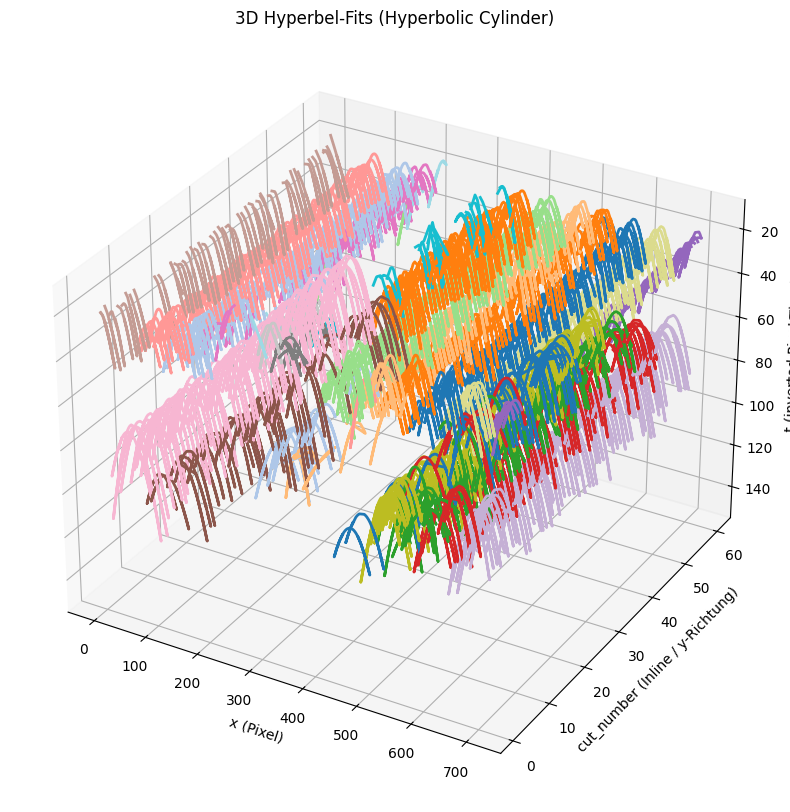

In [20]:
plot_hyperbolas_3d(fits_per_cut)

The next step is to create a fit function that produces an idealized result.
This means that a hyperbola fit is performed using all polygon data belonging to a bounding box.
The resulting fit is then extended across all cuts, forming a continuous surface.

This approach is useful because it produces a single set of parameters t₀, v, x₀ for each matched detection.
In other words, it provides a consolidated representation of all detected data per matched detection, resulting in a surface.

In [21]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import json

def fit_hyperbolas_idealized(df, csv:bool=False, csv_path:str = None,):

    # load data
    if csv:
        df = pd.read_csv(csv_path)
    else:
        df = df

    fits = []

    # group by bbox_number
    grouped = df.groupby("bbox_number")

    for bbox, group in grouped:
        #Fit Hyperbolas with multiplie Regression
        every_x = []
        every_t = []

        # get filenames and cut numbers for reference
        filenames = group["filename"].unique().tolist()
        cuts = group["cut_number"].unique().tolist()

        # iterate over each row in the group
        for i, row in group.iterrows():

            polygon =  json.loads(row["polygon_data"])
            polygon = np.array(polygon)
            x = polygon[:,0]
            t = polygon[:,1]

            every_x.append(x)
            every_t.append(t)
        
        # concatenate all x and t values for this bbox
        every_x = np.hstack(every_x)
        every_t = np.hstack(every_t)

        # define design matrix for fit
        y = every_t**2
        X = np.column_stack([np.ones_like(every_x), every_x, every_x**2])

        # load and fit model
        model = LinearRegression(fit_intercept=False)
        model.fit(X,y)

        # get coefficients
        print(f"fit for bbox: {bbox}, coefficients{model.coef_}")
        b0, b1, b2 = model.coef_

        #Convert Coefficients to Hyperbel context
        v = np.sqrt((4/b2))
        x0 = (-b1) / (2*b2)
        t0 = np.sqrt(b0 -b1**2 / ( 4*b2))

        # store fit results
        fits.append({
            "bbox": bbox,
            "filename": filenames,
            "cut_number": cuts,
            "b0_Model": b0,
            "b1_Model": b1,
            "b2_Model": b2,
            "v":v,
            "x0":x0,
            "t0":t0,
            "X_Data":every_x,
            "t_data":every_t
        })
    
    fits_df = pd.DataFrame(fits)

    
    return fits_df




    

In [22]:
idelaized_fit = fit_hyperbolas_idealized(df=matched_detections)

fit for bbox: 0, coefficients[ 6.2691e+05     -2143.7      1.8339]
fit for bbox: 1, coefficients[      39596     -539.76      1.8643]
fit for bbox: 2, coefficients[ 4.8715e+05     -1836.9       1.733]
fit for bbox: 3, coefficients[ 3.2576e+05     -1348.3      1.3971]
fit for bbox: 4, coefficients[ 6.8414e+05     -2424.8      2.1645]
fit for bbox: 5, coefficients[ 2.5041e+05     -1180.6      1.3942]
fit for bbox: 6, coefficients[ 9.9221e+05     -3270.4      2.7067]
fit for bbox: 7, coefficients[      14840     -326.47      1.8649]
fit for bbox: 8, coefficients[   8.59e+05     -2446.8      1.7433]
fit for bbox: 9, coefficients[ 1.1035e+06     -3291.6       2.464]
fit for bbox: 10, coefficients[      49922      -769.1      3.4896]
fit for bbox: 11, coefficients[     473.16      6.4169      1.4186]
fit for bbox: 12, coefficients[      56602     -588.75      1.5435]
fit for bbox: 13, coefficients[      10688     -251.64      2.9791]
fit for bbox: 14, coefficients[ 1.0078e+05     -669.55    

In [23]:
idelaized_fit

,bbox,filename,cut_number,b0_Model,b1_Model,b2_Model,v,x0,t0,X_Data,t_data
0,0,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",6.269087e+05,-2143.713329,1.833857,1.476887,584.482106,20.681063,"[575.4656372070312, 575.4656372070312, 572.132...","[11.140625, 15.584375381469727, 18.91718864440..."
1,1,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",3.959594e+04,-539.756969,1.864254,1.464797,144.764885,22.956697,"[133.3125, 133.3125, 132.20156860351562, 132.2...","[6.696875095367432, 11.140625, 12.251563072204..."
2,2,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 16, 17, 18, 19, 2, 20,...",4.871527e+05,-1836.940127,1.732996,1.519257,529.989683,19.315015,"[522.140625, 522.140625, 518.8078002929688, 51...","[11.140625, 14.473437309265137, 17.80624961853..."
3,3,[UG3DQUERUNTERZUG.SGY],"[1, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20,...",3.257609e+05,-1348.256276,1.397072,1.692079,482.529165,21.780803,"[469.92657470703125, 469.92657470703125, 466.5...","[11.140625, 15.584375381469727, 18.91718864440..."
4,4,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20...",6.841432e+05,-2424.842780,2.164461,1.359425,560.149331,70.754385,"[543.2484130859375, 543.2484130859375, 534.360...","[60.02187728881836, 63.35468673706055, 72.2421..."
5,5,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",2.504131e+05,-1180.563693,1.394210,1.693815,423.380902,22.338956,"[415.4906311035156, 415.4906311035156, 413.268...","[6.696875095367432, 10.029687881469727, 12.251..."
6,6,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",9.922132e+05,-3270.449720,2.706734,1.215646,604.132192,65.735796,"[596.5734252929688, 596.5734252929688, 595.462...","[55.578125, 60.02187728881836, 61.1328125, 61...."
7,7,[UG3DQUERUNTERZUG.SGY],"[1, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2, 20,...",1.483991e+04,-326.474845,1.864926,1.464533,87.530251,23.488197,"[78.8765640258789, 78.8765640258789, 77.765625...","[11.140625, 14.473437309265137, 15.58437538146..."
8,8,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",8.590036e+05,-2446.804316,1.743261,1.514777,701.789485,20.804482,"[693.2249755859375, 693.2249755859375, 692.114...","[11.140625, 15.584375381469727, 16.6953125, 17..."
9,9,[UG3DQUERUNTERZUG.SGY],"[1, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2,...",1.103490e+06,-3291.599079,2.464028,1.274111,667.930414,64.888787,"[668.7843627929688, 668.7843627929688, 666.562...","[46.69062423706055, 50.0234375, 52.24531173706..."


Finally, a function is created that performs both types of fits and returns both DataFrames, so that only a single function needs to be called to run the complete fitting process.

In [ ]:
import pandas as pd

def fit_hyperbolas(matched_detections, export_csv:bool = False, save_path:str = None):
    
    # fit both types
    idelaized_fit = fit_hyperbolas_idealized(df =matched_detections)
    fits_per_cut = fit_hyperbolas_on_every_cut(df=matched_detections)

    # export to CSV if needed
    if export_csv:
        idelaized_fit.to_csv(f"{save_path}/idealized_fit.csv", index=False)
        fits_per_cut.to_csv(f"{save_path}/fits_per_cut.csv", index=False)
        return idelaized_fit, fits_per_cut
    else:
        return idelaized_fit,fits_per_cut


    

In [10]:
idelaized_fit, fits_per_cut = fit_hyperbolas(matched_detections=matched_detections)

fit for bbox: 0, coefficients[   6.31e+05     -2157.3       1.845]
fit for bbox: 1, coefficients[      39885     -543.38      1.8754]
fit for bbox: 2, coefficients[ 4.8424e+05       -1826      1.7228]
fit for bbox: 3, coefficients[ 3.2972e+05     -1363.3      1.4113]
fit for bbox: 4, coefficients[   6.64e+05       -2350      2.0951]
fit for bbox: 5, coefficients[  2.588e+05     -1218.9      1.4379]
fit for bbox: 6, coefficients[ 1.0113e+06       -3333      2.7579]
fit for bbox: 7, coefficients[      14845     -326.88      1.8692]
fit for bbox: 8, coefficients[ 8.8233e+05     -2514.1      1.7918]
fit for bbox: 9, coefficients[ 1.1115e+06     -3311.5      2.4758]
fit for bbox: 10, coefficients[ 1.0166e+05     -676.93      1.1321]
fit for bbox: 11, coefficients[ 1.1808e+05     -884.27      1.6604]
fit for bbox: 12, coefficients[ 6.8398e+05       -2149      1.6892]
fit for bbox: 13, coefficients[      10686     -252.47      3.0009]
fit for bbox: 14, coefficients[      49812      -767.8    

### Chapter 6: Interactive Plot

There are now two fitting options, but the values obtained are pixel values.
The next step is to translate these pixel values into the actual data values.
Important information such as the Trace_Sample_Interval is extracted from the binary file header or the trace header.
With this information, the time axis can be calculated.

For the spatial axis in meters (crosslines), the only available information comes from the videos, indicating a spacing of approximately 4 meters.

The next step is to implement a function that computes the time axis from the header information, with additional parameters that can be used as input for the crossline axis and inline axis

In [24]:
#Loading SGY File with Datatoolkit
from Pipeline.Datatoolkit import DatatoolKit
dk = DatatoolKit(TEST_FILE_DIR , "UG3DQUERUNTERZUG.SGY")
file = dk.LoadSGY()
df = dk.create_df(file)


In [25]:
import segyio

def get_axis_and_sample_rate(sgy_file,df):

    # get number of unique crosslines and inlines
    number_of_crosslines = len(df["crossline"].unique())
    number_of_inlines = len(df["inline"].unique())

    # get bin header info in terms of sample rate
    bin_header_file = dict(sgy_file.bin)
    sampels_per_trace = bin_header_file[segyio.BinField.Samples]
    sample_rate = bin_header_file[segyio.BinField.Interval]

    return number_of_crosslines, number_of_inlines, sampels_per_trace, sample_rate


def help_function_physical_units(sample_rate, sample_rate_factor, number_of_crosslines, number_of_inlines, width_crosslines:int = None, width_inlines:int = None):
    #getting the time per pixel
    time_per_pixel = sample_rate/sample_rate_factor

    #getting distance per pixel for crossline
    distance_per_pixel_crosslines = width_crosslines/number_of_crosslines

    #getting distance per pixel for inlines
    distance_per_pixel_inlines = width_inlines/number_of_inlines

    return time_per_pixel, distance_per_pixel_crosslines, distance_per_pixel_inlines

def convert_phys_params(df, dcrosslines, dtime):

    # convert to physical units
    dcrosslines = float(dcrosslines)
    dtime = float(dtime)
    df = df.copy()
    df["x0_m"] = df["x0"] * dcrosslines
    df["t0_ns"] = df["t0"] * dtime
    df["v_m/ns"] = df["v"] * (dcrosslines/dtime)
    return df

Now, a 3D interactive plot function is implemented to provide deeper insight into the fitted data.
The plot contains several tabs:

- Detected polygons in a 3D context

- Fits per cut

- Apexes of the fits per cut

- Idealized fit plot

- Apexes of the idealized fit displayed as a line

In [ ]:
import plotly.io as pio
pio.renderers.default = "browser"

import plotly.graph_objects as go
import numpy as np
import json
from matplotlib.cm import get_cmap


def plot_hyperbolas_3d_interactive(
        fits_per_cut_df, fit_idealized_df, matched_detections,
        physics_enabled, sample_rate_factor=1000,
        width_crosslines=None, width_inlines=None):

    # Load SGY File to get Axis and Sample Rate Info
    number_of_crosslines, number_of_inlines, sampels_per_trace, sample_rate = \
        get_axis_and_sample_rate(sgy_file=file, df=df)

    # Convert to physical units if enabled
    if physics_enabled:
        if width_inlines is None or width_crosslines is None:
            raise ValueError("Width Inline or Width crosslines cant be empty when physics enabled")

        # Get physical units conversion factors
        time_per_pixel, distance_per_pixel_crosslines, distance_per_pixel_inlines = \
            help_function_physical_units(
                sample_rate=sample_rate,
                sample_rate_factor=sample_rate_factor,
                number_of_crosslines=number_of_crosslines,
                number_of_inlines=number_of_inlines,
                width_crosslines=width_crosslines,
                width_inlines=width_inlines
            )
        
        # Convert fit parameters to physical units
        fits_per_cut_df = convert_phys_params(
            df=fits_per_cut_df,
            dcrosslines=distance_per_pixel_crosslines,
            dtime=time_per_pixel
        )

        # Convert idealized fit parameters to physical units
        fit_idealized_df = convert_phys_params(
            df=fit_idealized_df,
            dcrosslines=distance_per_pixel_crosslines,
            dtime=time_per_pixel
        )

    # FIGURE
    fig = go.Figure()
    cmap = get_cmap("tab20")

    # Initialize trace lists
    traces_hyper = []
    traces_apex = []
    traces_poly = []
    traces_surface = []
    traces_surface_apex = []

    # Idealized Hyperbel Surfaces + Apex-Lines
    for _, row in fit_idealized_df.iterrows():

        # getting parameters
        bbox = int(row["bbox"])
        v_raw, x0_raw, t0_raw = row["v"], row["x0"], row["t0"]

        # surface color
        r, g, b, a = cmap(bbox % 20)
        col = f"rgba({255*r:.0f},{255*g:.0f},{255*b:.0f},0.7)"

        # surface grid limits
        xmin, xmax = min(row["X_Data"]), max(row["X_Data"])
        cmin, cmax = 0, number_of_inlines -1

        # surface points
        xf = np.linspace(xmin, xmax, 60)
        yf = np.linspace(cmin, cmax, 60)

        # create meshgrid
        Xg, Yg = np.meshgrid(xf, yf)
        Zg = np.sqrt((4 / v_raw**2) * (Xg - x0_raw)**2 + t0_raw**2)

        # surface trace
        traces_surface.append(len(fig.data))
        fig.add_trace(go.Surface(
            x=Xg, y=Yg, z=Zg,
            opacity=0.5,
            showscale=False,
            colorscale=[[0, col], [1, col]],
            visible=False
        ))

        # apex lines
        y_line = np.linspace(cmin, cmax, 50)
        x_line = np.full_like(y_line, x0_raw)
        z_line = np.full_like(y_line, t0_raw)

        # Hover Data
        if physics_enabled:
            x0_m = row["x0_m"]
            t0_ns = row["t0_ns"]
            v_m_ns = row["v_m/ns"]

            # hover template with physical units
            hovertemplate = (
                "<b>Idealisiert Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px (%{customdata[1]:.3f} m)<br>"
                "t0 = %{customdata[2]:.1f} samp (%{customdata[3]:.1f} ns)<br>"
                "v = %{customdata[4]:.3f} px/samp (%{customdata[5]:.6f} m/ns)<br>"
                "<extra></extra>"
            )

            # customdata base
            base = [x0_raw, x0_m, t0_raw, t0_ns, v_raw, v_m_ns]

        else:

            # hover template without physical units
            hovertemplate = (
                "<b>Idealisiert Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px<br>"
                "t0 = %{customdata[1]:.1f} samp<br>"
                "v = %{customdata[2]:.2f} px/samp<br>"
                "<extra></extra>"
            )

            # customdata base
            base = [x0_raw, t0_raw, v_raw]

        # customdata for all points
        customdata = np.tile([base], (len(x_line), 1))

        traces_surface_apex.append(len(fig.data))
        fig.add_trace(
            go.Scatter3d(
                x=x_line, y=y_line, z=z_line,
                mode="lines",
                line=dict(color=col, width=5),
                visible=False,
                hovertemplate=hovertemplate,
                hoverinfo="text",
                customdata=customdata
            )
        )

    # Hyperbolas per Cut and Apex Points
    for _, row in fits_per_cut_df.iterrows():
        
        # getting parameters
        bbox = int(row["bbox_number"])
        cut = int(row["cut_number"])
        X = np.array(row["X_Data"])

        # getting raw parameters
        v_raw, x0_raw, t0_raw = row["v"], row["x0"], row["t0"]

        # surface color
        r, g, b, a = cmap(bbox % 20)
        col = f"rgba({255*r:.0f},{255*g:.0f},{255*b:.0f},{a})"

        # hyperbola points
        xf = np.linspace(X.min(), X.max(), 150)
        yf = np.full_like(xf, cut)
        tf = np.sqrt((4 / v_raw**2) * (xf - x0_raw)**2 + t0_raw**2)

        # Hyperbel Trace
        traces_hyper.append(len(fig.data))
        fig.add_trace(go.Scatter3d(
            x=xf, y=yf, z=tf,
            mode="lines",
            line=dict(color=col, width=4),
            visible=True
        ))

        # Apex Point Hover Data
        if physics_enabled:
            x0_m = row["x0_m"]
            t0_ns = row["t0_ns"]
            v_m_ns = row["v_m/ns"]

            # hover template with physical units
            hovertemplate = (
                "<b>Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px (%{customdata[1]:.3f} m)<br>"
                "t0 = %{customdata[2]:.1f} samp (%{customdata[3]:.1f} ns)<br>"
                "v = %{customdata[4]:.3f} px/samp (%{customdata[5]:.6f} m/ns)<br>"
                "<extra></extra>"
            )

            # customdata with physical units
            customdata = [[x0_raw, x0_m, t0_raw, t0_ns, v_raw, v_m_ns]]

        else:

            # hover template without physical units
            hovertemplate = (
                "<b>Apex</b><br>"
                "x0 = %{customdata[0]:.1f} px<br>"
                "t0 = %{customdata[1]:.1f} samp<br>"
                "v = %{customdata[2]:.2f} px/samp<br>"
                "<extra></extra>"
            )

            #  customdata without physical units
            customdata = [[x0_raw, t0_raw, v_raw]]

        # Apex Point Trace
        traces_apex.append(len(fig.data))
        fig.add_trace(go.Scatter3d(
            x=[x0_raw], y=[cut], z=[t0_raw],
            mode="markers",
            marker=dict(size=6, color=col),
            visible=False,
            hovertemplate=hovertemplate,
            customdata=customdata
        ))

    # Detected Polygons
    for _, row in matched_detections.iterrows():

        # parse polygon data
        try:
            poly = json.loads(row["polygon_data"])
        except:
            continue
        
        # skip if polygon is empty or invalid
        xs = [p[0] for p in poly]
        zs = [p[1] for p in poly]
        ys = [row["cut_number"]] * len(xs)

        if len(xs) < 2:
            continue
        
        # color based on bbox number
        bbox = int(row["bbox_number"])
        r, g, b, a = cmap(bbox % 20)
        col = f"rgba({255*r:.0f},{255*g:.0f},{255*b:.0f},{a})"

        # polygon trace
        traces_poly.append(len(fig.data))
        fig.add_trace(go.Scatter3d(
            x=xs, y=ys, z=zs,
            mode="lines",
            line=dict(color=col, width=3),
            visible=False
        ))

    # visibility mask function
    def mask(traces):
        vis = [False] * len(fig.data)
        for t in traces:
            vis[t] = True
        return vis

    # update layout with buttons
    fig.update_layout(
        title="<b>Detektionen und Hyperbeln</b>",
        scene=dict(
            xaxis=dict(title="Crosslines"),
            yaxis=dict(title="Inlines"),
            zaxis=dict(title="Zeit (Samples)", range=[sampels_per_trace, 0])
        ),
        updatemenus=[
            dict(
                type="buttons",
                buttons=[
                    dict(label="Polygone Detektiert",
                         method="update",
                         args=[{"visible": mask(traces_poly)}]),
                    dict(label="Hyperbeln Pro Cut",
                         method="update",
                         args=[{"visible": mask(traces_hyper)}]),
                    dict(label="Scheitelpunkte Pro Hyperbel",
                         method="update",
                         args=[{"visible": mask(traces_apex)}]),
                    dict(label="Hyperbeln Idealisiert",
                         method="update",
                         args=[{"visible": mask(traces_surface)}]),
                    dict(label="Scheitelpunkte Idealisiert",
                         method="update",
                         args=[{"visible": mask(traces_surface_apex)}]),
                ],
                x=0, y=0.85
            )
        ],
        height=700
    )

    fig.show()


In [34]:
plot_hyperbolas_3d_interactive(fits_per_cut_df=fits_per_cut,fit_idealized_df=idelaized_fit,matched_detections=matched_detections,physics_enabled=True,width_crosslines=4, width_inlines=3)

C:\Users\Joris Gisler\AppData\Local\Temp\ipykernel_10584\2187797309.py:51: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



### Chapter 4: Implementation in Pipeline

With this notebook many methods where implemented in the Predictor class they are listed afterwards:

- **match_detections()** from chapter 4
- **validate-detections()** from Chapter 4
- **fit_hyperbolas_on_every_cut** from Chapter 5
- **fit_hyperbolas_idealized()** from Chapter 5
- **fit_hyperbolas()** from Chapter 5
- **get_axis_and_sample_rate** from Chapter 5
- **help_function_physical_units()** from Chapter 6
- **convert_phys_params()** from Chapter 6
- **plot_hyperbolas_3d_interactive()** from Chapter 6

the exact parameters the methods are needing and the final implementations are documented in the Predictor class.

